# 03 - Avaliacao e testes

Objetivo: carregar o modelo treinado, calcular metricas, visualizar a matriz de confusao e testar previsoes novas.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

DATA_DIR = PROJECT_ROOT / "data" / "raw" / "aclImdb"
MODELS_DIR = PROJECT_ROOT / "models"
MODELS_DIR.mkdir(exist_ok=True)

print("Projeto:", PROJECT_ROOT)
print("Dados:", DATA_DIR)


Projeto: C:\Users\Carlos henrique\Documents\deeplearning
Dados: C:\Users\Carlos henrique\Documents\deeplearning\data\raw\aclImdb


In [2]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_recall_fscore_support

from src.imdb_data import load_reviews

sns.set_theme(style="whitegrid")
print("TensorFlow:", tf.__version__)


def clean_text_array(values):
    cleaned = []
    for text in values:
        text = text.replace("<br />", " ")
        text = text.encode("ascii", "ignore").decode("ascii")
        cleaned.append(text)
    return np.array(cleaned, dtype=object)


TensorFlow: 2.21.0


## Carregar teste e modelo

In [3]:
model_path = MODELS_DIR / "imdb_sentiment_model.keras"
if not model_path.exists():
    raise FileNotFoundError("Execute primeiro o notebook 02_preprocessamento_modelo.ipynb para gerar o modelo.")

model = tf.keras.models.load_model(model_path)
df = load_reviews(DATA_DIR)
test_df = df[df["split"] == "test"].sample(frac=1, random_state=42).reset_index(drop=True)

x_test = clean_text_array(test_df["review"].to_numpy())
y_test = test_df["target"].to_numpy()

print("Modelo carregado de:", model_path)
print("Amostras de teste:", len(test_df))


Modelo carregado de: C:\Users\Carlos henrique\Documents\deeplearning\models\imdb_sentiment_model.keras
Amostras de teste: 25000


## Metricas

In [4]:
probabilities = model.predict(x_test, batch_size=256, verbose=0).ravel()
y_pred = (probabilities >= 0.5).astype(int)

accuracy = accuracy_score(y_test, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average="binary")

metrics_df = pd.DataFrame(
    {
        "metrica": ["accuracy", "precision", "recall", "f1_score"],
        "valor": [accuracy, precision, recall, f1],
    }
)
metrics_df


,metrica,valor
0,accuracy,0.847680
1,precision,0.906929
2,recall,0.774880
3,f1_score,0.835720


In [5]:
print(classification_report(y_test, y_pred, target_names=["negativo", "positivo"]))


              precision    recall  f1-score   support

    negativo       0.80      0.92      0.86     12500
    positivo       0.91      0.77      0.84     12500

    accuracy                           0.85     25000
   macro avg       0.86      0.85      0.85     25000
weighted avg       0.86      0.85      0.85     25000



## Matriz de confusao

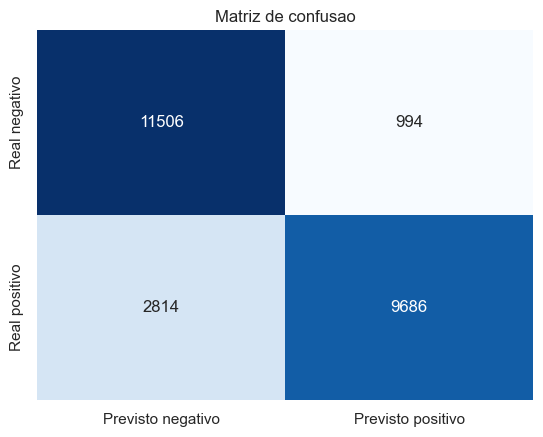

,Previsto negativo,Previsto positivo
Real negativo,11506,994
Real positivo,2814,9686


In [6]:
cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(cm, index=["Real negativo", "Real positivo"], columns=["Previsto negativo", "Previsto positivo"])

ax = sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues", cbar=False)
ax.set_title("Matriz de confusao")
plt.show()
cm_df


## Exemplos classificados errados

In [7]:
analysis_df = test_df.copy()
analysis_df["probabilidade_positivo"] = probabilities
analysis_df["predito"] = np.where(y_pred == 1, "pos", "neg")
analysis_df["correto"] = analysis_df["target"].to_numpy() == y_pred

erros = analysis_df[~analysis_df["correto"]].copy()
erros[["label", "predito", "probabilidade_positivo", "review"]].head(8)


,label,predito,probabilidade_positivo,review
0,neg,pos,0.619416,"I hate guns and have never murdered anyone, bu..."
2,neg,pos,0.897054,"I have seen this movie several times, it sure ..."
13,pos,neg,0.108825,No doubt about it. This is the animated short ...
16,pos,neg,0.255206,Fred was such a great show.It was simple but s...
32,pos,neg,0.105746,What-ho! This one is jolly good. I say jolly g...
43,pos,neg,0.211304,"In many ways, the filmic career of independent..."
49,pos,neg,0.263844,"I'm not going to go into too much depth, but S..."
56,pos,neg,0.349209,Two city guys are driving through Hicksville U...


## Previsoes com textos novos

In [8]:
novas_reviews = np.array([
    "This movie is amazing, emotional and beautifully acted.",
    "The story was boring, predictable and way too long.",
    "I liked the cast, but the script did not work for me.",
    "A fantastic film with great rhythm and memorable characters.",
], dtype=object)
novas_reviews_modelo = clean_text_array(novas_reviews)

novas_probs = model.predict(novas_reviews_modelo, verbose=0).ravel()
resultados = pd.DataFrame({
    "review": novas_reviews,
    "probabilidade_positivo": novas_probs,
})
resultados["classe_prevista"] = np.where(resultados["probabilidade_positivo"] >= 0.5, "positivo", "negativo")
resultados

,review,probabilidade_positivo,classe_prevista
0,"This movie is amazing, emotional and beautiful...",0.951574,positivo
1,"The story was boring, predictable and way too ...",0.072518,negativo
2,"I liked the cast, but the script did not work ...",0.348709,negativo
3,A fantastic film with great rhythm and memorab...,0.853952,positivo
